In [1]:
!pip install mlxtend -q

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)

In [4]:
df = pd.read_csv("Groceries_dataset.csv")

df.head()

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


In [5]:
df.head(20)

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk
5,4941,14-02-2015,rolls/buns
6,4501,08-05-2015,other vegetables
7,3803,23-12-2015,pot plants
8,2762,20-03-2015,whole milk
9,4119,12-02-2015,tropical fruit


In [6]:
df.tail()

,Member_number,Date,itemDescription
38760,4471,08-10-2014,sliced cheese
38761,2022,23-02-2014,candy
38762,1097,16-04-2014,cake bar
38763,1510,03-12-2014,fruit/vegetable juice
38764,1521,26-12-2014,cat food


In [7]:
df

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk
...,...,...,...
38760,4471,08-10-2014,sliced cheese
38761,2022,23-02-2014,candy
38762,1097,16-04-2014,cake bar
38763,1510,03-12-2014,fruit/vegetable juice


In [8]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 38765
Columns: 3


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38765 entries, 0 to 38764
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Member_number    38765 non-null  int64 
 1   Date             38765 non-null  object
 2   itemDescription  38765 non-null  object
dtypes: int64(1), object(2)
memory usage: 908.7+ KB


In [10]:
df.columns

Index(['Member_number', 'Date', 'itemDescription'], dtype='object')

Data Cleaning

In [11]:
df.isnull().sum()

,0
Member_number,0
Date,0
itemDescription,0


In [12]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 759


In [13]:
df['Date'] = pd.to_datetime(
    df['Date'],
    format='%d-%m-%Y'
)

print(df['Date'].head())

0   2015-07-21
1   2015-01-05
2   2015-09-19
3   2015-12-12
4   2015-02-01
Name: Date, dtype: datetime64[ns]


In [14]:
df = df.dropna()

remove duplicates

In [15]:
df = df.drop_duplicates()

In [16]:
print("Dataset shape:", df.shape)
print(df.isnull().sum())

Dataset shape: (38006, 3)
Member_number      0
Date               0
itemDescription    0
dtype: int64


number of customers

In [17]:
print("Unique Customers:",
      df['Member_number'].nunique())

Unique Customers: 3898


number of products

In [18]:
print("Unique Products:",
      df['itemDescription'].nunique())

Unique Products: 167


In [19]:
print("Start Date:", df['Date'].min())
print("End Date:", df['Date'].max())

Start Date: 2014-01-01 00:00:00
End Date: 2015-12-30 00:00:00


In [20]:
top_products = df['itemDescription'].value_counts().head(15)

print(top_products)

itemDescription
whole milk          2363
other vegetables    1827
rolls/buns          1646
soda                1453
yogurt              1285
root vegetables     1041
tropical fruit      1014
bottled water        908
sausage              903
citrus fruit         795
pastry               774
pip fruit            734
shopping bags        712
canned beer          702
bottled beer         678
Name: count, dtype: int64


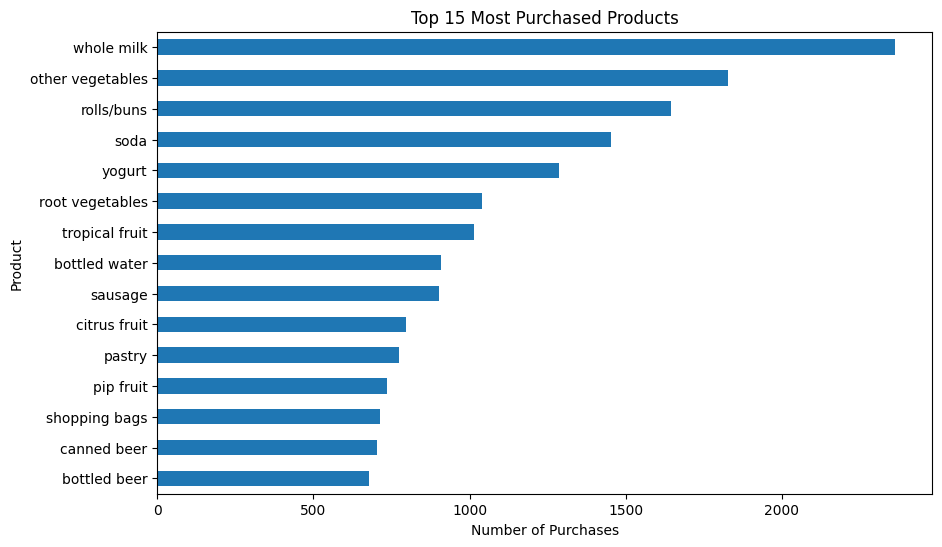

In [21]:
plt.figure(figsize=(10,6))

top_products.sort_values().plot(
    kind='barh'
)

plt.title("Top 15 Most Purchased Products")
plt.xlabel("Number of Purchases")
plt.ylabel("Product")

plt.show()

In [22]:
transactions_df = (
    df.groupby(
        ['Member_number', 'Date']
    )['itemDescription']
    .apply(list)
    .reset_index()
)

In [23]:
transactions_df

,Member_number,Date,itemDescription
0,1000,2014-06-24,"[whole milk, pastry, salty snack]"
1,1000,2015-03-15,"[sausage, whole milk, semi-finished bread, yog..."
2,1000,2015-05-27,"[soda, pickled vegetables]"
3,1000,2015-07-24,"[canned beer, misc. beverages]"
4,1000,2015-11-25,"[sausage, hygiene articles]"
...,...,...,...
14958,4999,2015-05-16,"[butter milk, whipped/sour cream]"
14959,4999,2015-12-26,"[bottled water, herbs]"
14960,5000,2014-03-09,"[fruit/vegetable juice, onions]"
14961,5000,2014-11-16,"[bottled beer, other vegetables]"


In [24]:
transactions_df.head()

,Member_number,Date,itemDescription
0,1000,2014-06-24,"[whole milk, pastry, salty snack]"
1,1000,2015-03-15,"[sausage, whole milk, semi-finished bread, yog..."
2,1000,2015-05-27,"[soda, pickled vegetables]"
3,1000,2015-07-24,"[canned beer, misc. beverages]"
4,1000,2015-11-25,"[sausage, hygiene articles]"


In [25]:
transactions_df.iloc[0]['itemDescription']

['whole milk', 'pastry', 'salty snack']

In [26]:
transactions = transactions_df['itemDescription'].tolist()

print("Total Transactions:", len(transactions))

Total Transactions: 14963


In [27]:
te = TransactionEncoder()

te_array = te.fit(
    transactions
).transform(
    transactions
)

basket = pd.DataFrame(
    te_array,
    columns=te.columns_
)

In [28]:
basket.head()

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [29]:
product_frequency = basket.sum().sort_values(
    ascending=False
)

product_frequency.head(15)

,0
whole milk,2363
other vegetables,1827
rolls/buns,1646
soda,1453
yogurt,1285
root vegetables,1041
tropical fruit,1014
bottled water,908
sausage,903
citrus fruit,795


Apriori

In [30]:
frequent_itemsets_apriori = apriori(
    basket,
    min_support=0.01,
    use_colnames=True
)

In [31]:
print(
    "Frequent Itemsets:",
    len(frequent_itemsets_apriori)
)

Frequent Itemsets: 69


In [32]:
frequent_itemsets_apriori.sort_values(
    by='support',
    ascending=False
).head(20)

,support,itemsets
62,0.157923,(whole milk)
40,0.122101,(other vegetables)
46,0.110005,(rolls/buns)
52,0.097106,(soda)
63,0.085879,(yogurt)
47,0.069572,(root vegetables)
57,0.067767,(tropical fruit)
5,0.060683,(bottled water)
49,0.060349,(sausage)
15,0.053131,(citrus fruit)


In [33]:
rules_apriori = association_rules(
    frequent_itemsets_apriori,
    metric='confidence',
    min_threshold=0.1
)

In [34]:
print("Association Rules:",
    len(rules_apriori)
)

Association Rules: 4


In [35]:
rules_apriori[
    [
        'antecedents',
        'consequents',
        'support',
        'confidence',
        'lift'
    ]
].head(20)

,antecedents,consequents,support,confidence,lift
0,(other vegetables),(whole milk),0.014837,0.121511,0.769430
1,(rolls/buns),(whole milk),0.013968,0.126974,0.804028
2,(soda),(whole milk),0.011629,0.119752,0.758296
3,(yogurt),(whole milk),0.011161,0.129961,0.822940


FP-Growth

In [36]:
frequent_itemsets_fp = fpgrowth(
    basket,
    min_support=0.01,
    use_colnames=True
)

In [37]:
print("FP-Growth Itemsets:",
    len(frequent_itemsets_fp)
)

FP-Growth Itemsets: 69


In [38]:
frequent_itemsets_fp.sort_values(
    by='support',
    ascending=False
).head(20)

,support,itemsets
0,0.157923,(whole milk)
15,0.122101,(other vegetables)
9,0.110005,(rolls/buns)
5,0.097106,(soda)
3,0.085879,(yogurt)
23,0.069572,(root vegetables)
18,0.067767,(tropical fruit)
29,0.060683,(bottled water)
4,0.060349,(sausage)
42,0.053131,(citrus fruit)


In [39]:
rules_fp = association_rules(
    frequent_itemsets_fp,
    metric='confidence',
    min_threshold=0.1
)

In [40]:
print(
    "FP-Growth Rules:",
    len(rules_fp)
)

FP-Growth Rules: 4


In [41]:
rules_fp[
    [
        'antecedents',
        'consequents',
        'support',
        'confidence',
        'lift'
    ]
].head(20)

,antecedents,consequents,support,confidence,lift
0,(yogurt),(whole milk),0.011161,0.129961,0.822940
1,(soda),(whole milk),0.011629,0.119752,0.758296
2,(rolls/buns),(whole milk),0.013968,0.126974,0.804028
3,(other vegetables),(whole milk),0.014837,0.121511,0.769430


In [42]:
comparison = pd.DataFrame({
    'Algorithm': [
        'Apriori',
        'FP-Growth'
    ],

    'Frequent Itemsets': [
        len(frequent_itemsets_apriori),
        len(frequent_itemsets_fp)
    ],

    'Association Rules': [
        len(rules_apriori),
        len(rules_fp)
    ]
})

comparison

,Algorithm,Frequent Itemsets,Association Rules
0,Apriori,69,4
1,FP-Growth,69,4


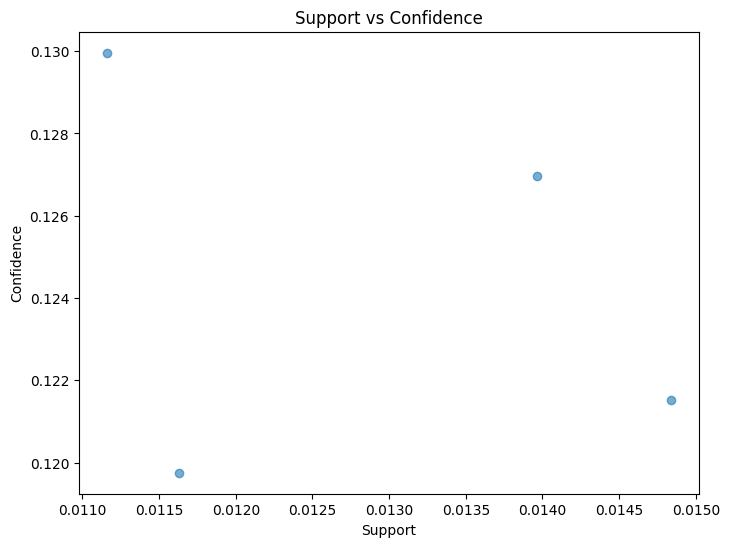

In [43]:
plt.figure(figsize=(8,6))

plt.scatter(
    rules_apriori['support'],
    rules_apriori['confidence'],
    alpha=0.6
)

plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Support vs Confidence")

plt.show()

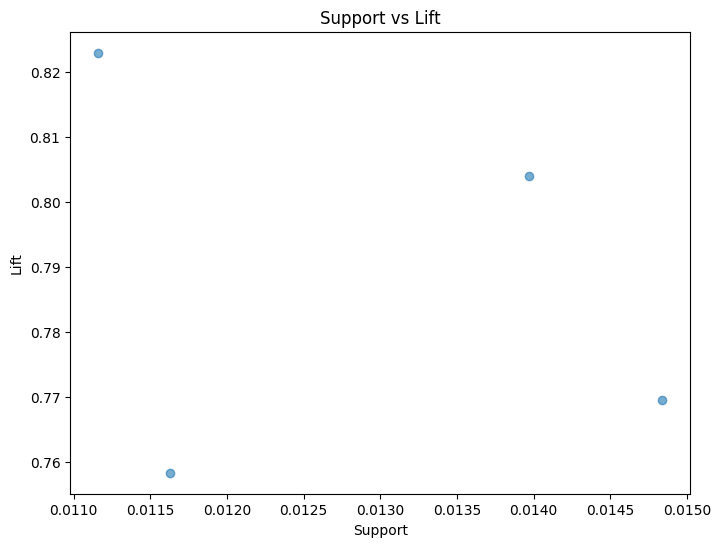

In [44]:
plt.figure(figsize=(8,6))

plt.scatter(
    rules_apriori['support'],
    rules_apriori['lift'],
    alpha=0.6
)

plt.xlabel("Support")
plt.ylabel("Lift")
plt.title("Support vs Lift")

plt.show()